<div style="background:linear-gradient(135deg,#0a0f1e,#0d1f3c,#0a2744);padding:44px 36px;border-radius:16px;text-align:center;border:1px solid #1a4a7a">
<h1 style="color:#00d4ff;font-size:2.4em;font-weight:800"> Anti-Money Laundering Detection</h1>
<h3 style="color:#7ecfff;font-weight:400">Transaction Network Analysis + Boosting Classifiers on the SAML-D Dataset</h3>
<div style="display:flex;justify-content:center;gap:10px;flex-wrap:wrap;margin-top:16px">
<span style="background:#006994;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">NetworkX</span>
<span style="background:#2e7d32;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">XGBoost</span>
<span style="background:#5a3e85;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">LightGBM</span>
<span style="background:#7b3f00;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">CatBoost</span>
<span style="background:#b71c1c;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">SMOTE</span>
<span style="background:#1a4a7a;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">SAML-D Dataset</span>
</div></div>

## Abstract

Traditional AML detection treats every transaction as an **isolated record**. This misses the most powerful signal available: the **network structure** of money flows.

Money laundering is inherently relational — it requires chains of accounts, layering through multiple hops, and patterns like *smurfing* (breaking large amounts into many small transfers). These patterns are invisible to row-by-row classifiers but immediately apparent in a transaction graph.

This notebook builds a **two-stage detection pipeline** combining:

1. **Graph-based feature engineering** (NetworkX) — structural signals from the transaction network: degree centrality, betweenness, PageRank, community membership, and suspicious subgraph flags
2. **Gradient-boosting classifiers** (XGBoost · LightGBM · CatBoost) — trained on both raw tabular features *and* graph-derived features

| Approach | What it sees | What it misses |
|---|---|---|
| Tabular ML only | Amount, time, payment type | Network position, layering chains |
| Rule-based AML | Known patterns | Novel laundering schemes |
| **Graph + ML (this notebook)** | **Both tabular and relational signals** | **Very little** |

### AML typologies detected via graph analysis
- **Layering chains** → high betweenness centrality nodes
- **Smurfing / structuring** → high in-degree nodes receiving many small transfers
- **Shell company networks** → dense communities with high internal edge weights
- **Mule accounts** → nodes with both high in-degree and high out-degree

---

## Table of Contents

1. [Environment Setup](#1)
2. [Data Loading & Overview](#2)
3. [Exploratory Data Analysis](#3)
4. [Transaction Network Construction (NetworkX)](#4)
5. [Graph Topology Analysis](#5)
6. [Suspicious Pattern Detection in the Graph](#6)
7. [Graph Feature Engineering](#7)
8. [Feature Preparation & SMOTE](#8)
9. [XGBoost Classifier](#9)
10. [LightGBM Classifier](#10)
11. [CatBoost Classifier](#11)
12. [Model Comparison & Evaluation Dashboard](#12)
13. [Graph-Enhanced Feature Importance](#13)
14. [Key Takeaways & Next Steps](#14)

---

## Environment Setup

In [1]:
# Uncomment if on a fresh environment
# !pip install networkx xgboost lightgbm catboost imbalanced-learn -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from collections import Counter, defaultdict
import networkx as nx
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, fbeta_score, recall_score)
from sklearn.metrics import auc as sk_auc
from imblearn.over_sampling import SMOTE
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="darkgrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi":120,"axes.titleweight":"bold","axes.titlesize":13})
SEED = 42; np.random.seed(SEED)
print(f"NetworkX {nx.__version__} | XGBoost {xgb.__version__} | LightGBM {lgb.__version__}")
print("✅ All imports successful")

NetworkX 3.6.1 | XGBoost 3.2.0 | LightGBM 4.6.0
✅ All imports successful


## Data Loading & Overview

### The SAML-D Dataset

The **Synthetic AML Dataset (SAML-D)** simulates real-world banking transaction monitoring data, designed to reflect the statistical properties of actual AML datasets used by financial institutions.

| Feature | Description | AML Relevance |
|---|---|---|
| `Sender_account` / `Receiver_account` | Account IDs | Nodes in the transaction graph |
| `Amount` | Transaction value (USD) | Structuring / threshold detection |
| `Payment_type` | Channel (wire, cash, card…) | Risk-by-channel profiling |
| `Sender/Receiver_bank_location` | Country of bank | Jurisdiction & corridor risk |
| `Date` / `Time` | Transaction timestamp | Temporal pattern analysis |
| `Is_laundering` | 0=normal, 1=suspicious | **Target variable** |
| `Laundering_type` | Sub-type of scheme | Typology analysis |


In [2]:
DATA_PATH = "/kaggle/input/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml/SAML-D.csv"
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])
df['hour']       = df['Time'].dt.hour
df['day_of_week']= df['Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['is_night']   = df['hour'].apply(lambda h: 1 if (h<7 or h>=22) else 0)
df['Amount_log'] = np.log1p(df['Amount'])
df['amount_tier']= pd.cut(df['Amount'],
    bins=[0,100,1_000,10_000,100_000,df['Amount'].max()],
    labels=['micro','small','medium','large','mega'])

n_total = len(df); n_fraud = df['Is_laundering'].sum(); n_legit = n_total - n_fraud
print(f"Transactions : {n_total:>12,}")
print(f"Fraudulent   : {n_fraud:>12,}  ({n_fraud/n_total*100:.3f}%)")
print(f"Legitimate   : {n_legit:>12,}  ({n_legit/n_total*100:.3f}%)")
print(f"Imbalance    : {n_legit/n_fraud:>12,.0f}:1")
print("\nLaundering types:")
print(df[df['Is_laundering']==1]['Laundering_type'].value_counts())

Transactions :    9,504,852
Fraudulent   :        9,873  (0.104%)
Legitimate   :    9,494,979  (99.896%)
Imbalance    :          962:1

Laundering types:
Laundering_type
Structuring             1870
Cash_Withdrawal         1334
Deposit-Send             945
Smurfing                 932
Layered_Fan_In           656
Layered_Fan_Out          529
Stacked Bipartite        506
Behavioural_Change_1     394
Bipartite                383
Cycle                    382
Fan_In                   364
Gather-Scatter           354
Behavioural_Change_2     345
Scatter-Gather           338
Single_large             250
Fan_Out                  237
Over-Invoicing            54
Name: count, dtype: int64


## Exploratory Data Analysis

Each chart answers a specific AML question. Together they profile the six core risk dimensions of the dataset.

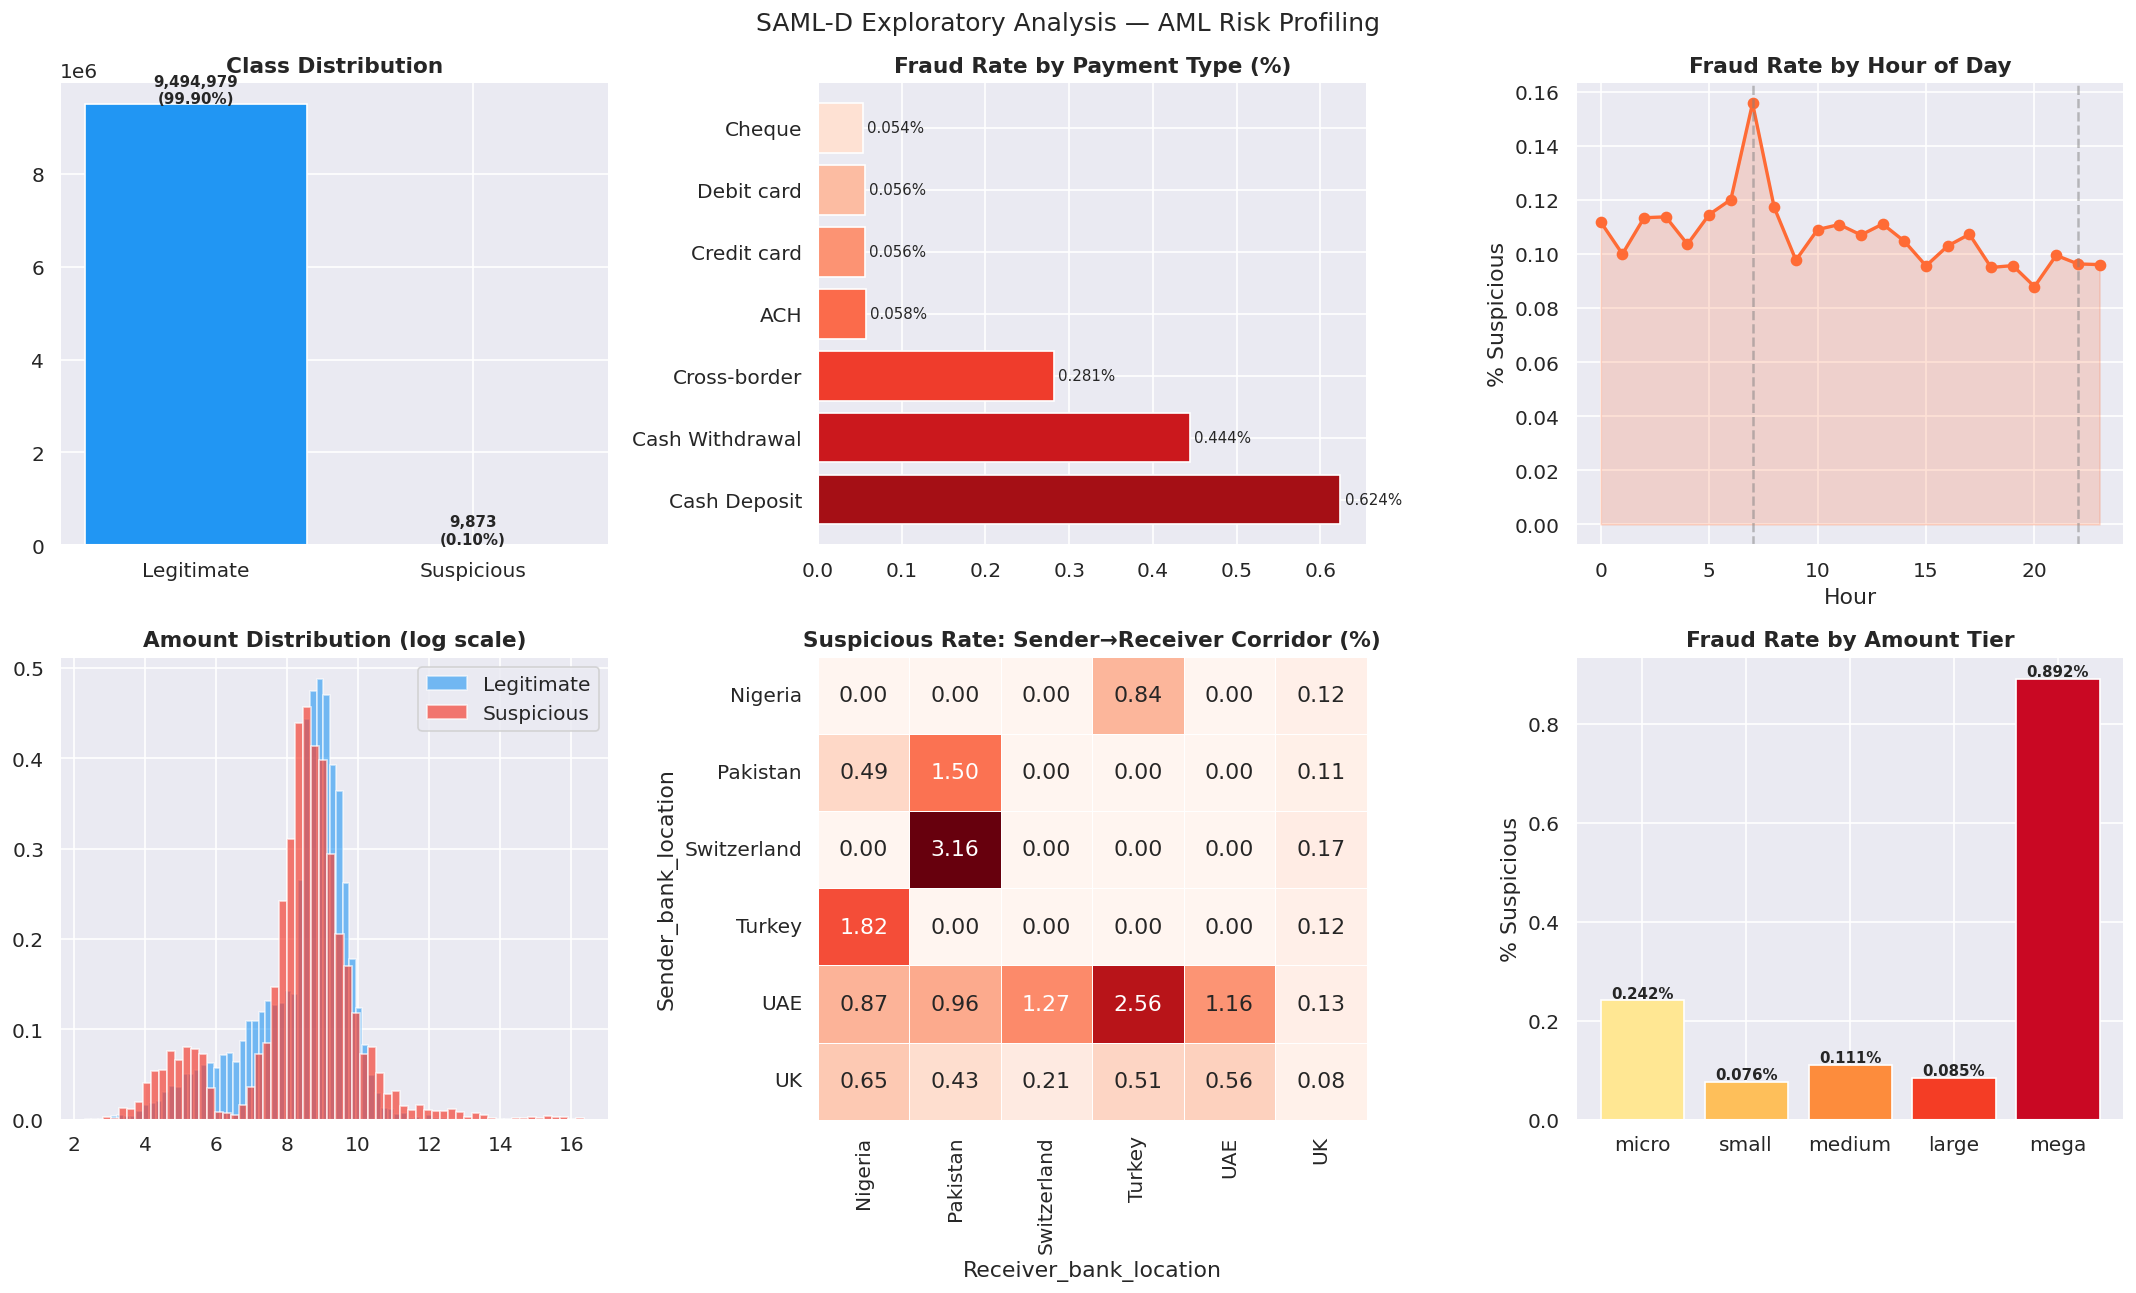

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18,11))
fig.suptitle("SAML-D Exploratory Analysis — AML Risk Profiling", fontsize=15)

# 1. Class imbalance
vc = df['Is_laundering'].value_counts()
axes[0,0].bar(['Legitimate','Suspicious'], vc.values, color=['#2196F3','#F44336'], edgecolor='white')
axes[0,0].set_title("Class Distribution")
for i,(k,v) in enumerate(vc.items()):
    axes[0,0].text(i, v+n_total*0.002, f"{v:,}\n({v/n_total*100:.2f}%)", ha='center', fontsize=9, fontweight='bold')

# 2. Fraud rate by payment type
pt = df.groupby('Payment_type')['Is_laundering'].mean().sort_values(ascending=False)*100
axes[0,1].barh(pt.index, pt.values, color=sns.color_palette("Reds_r", len(pt)))
axes[0,1].set_title("Fraud Rate by Payment Type (%)")
for i,v in enumerate(pt.values): axes[0,1].text(v+0.005, i, f"{v:.3f}%", va='center', fontsize=9)

# 3. Fraud rate by hour
hr = df.groupby('hour')['Is_laundering'].mean()*100
axes[0,2].plot(hr.index, hr.values, marker='o', color='#FF6B35', linewidth=2)
axes[0,2].fill_between(hr.index, hr.values, alpha=0.2, color='#FF6B35')
axes[0,2].set_title("Fraud Rate by Hour of Day"); axes[0,2].set_xlabel("Hour"); axes[0,2].set_ylabel("% Suspicious")
axes[0,2].axvline(7, color='gray', linestyle='--', alpha=0.5); axes[0,2].axvline(22, color='gray', linestyle='--', alpha=0.5)

# 4. Amount distribution
fa = df[df['Is_laundering']==1]['Amount_log']
la = df[df['Is_laundering']==0]['Amount_log'].sample(10000, random_state=SEED)
axes[1,0].hist(la, bins=60, alpha=0.6, color='#2196F3', density=True, label='Legitimate')
axes[1,0].hist(fa, bins=60, alpha=0.7, color='#F44336', density=True, label='Suspicious')
axes[1,0].set_title("Amount Distribution (log scale)"); axes[1,0].legend()

# 5. Corridor heatmap
top_c = df['Sender_bank_location'].value_counts().head(6).index
corr = pd.crosstab(df['Sender_bank_location'], df['Receiver_bank_location'],
    values=df['Is_laundering'], aggfunc='mean')*100
corr_sub = corr.loc[corr.index.isin(top_c), corr.columns.isin(top_c)].fillna(0)
sns.heatmap(corr_sub, annot=True, fmt='.2f', cmap='Reds', ax=axes[1,1], cbar=False, linewidths=0.3)
axes[1,1].set_title("Suspicious Rate: Sender→Receiver Corridor (%)")

# 6. Fraud by amount tier
tier = df.groupby('amount_tier', observed=True)['Is_laundering'].mean()*100
axes[1,2].bar(tier.index.astype(str), tier.values, color=sns.color_palette("YlOrRd",len(tier)), edgecolor='white')
axes[1,2].set_title("Fraud Rate by Amount Tier"); axes[1,2].set_ylabel("% Suspicious")
for i,v in enumerate(tier.values): axes[1,2].text(i, v+0.005, f"{v:.3f}%", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

## Transaction Network Construction (NetworkX)

### Why model transactions as a graph?

A transaction network is a **weighted directed graph**:
- **Nodes** = bank accounts
- **Directed edges** = money flows (A→B means A sent to B)
- **Edge weights** = total transaction amount on that corridor

This structure naturally encodes AML typologies:

```
Normal account:    few edges, small amounts, local neighbourhood
Mule account:      many in-edges from diverse sources + out-edges to few destinations
Shell company:     appears in a tight cluster, high betweenness within the cluster
Structuring node:  many in-edges with amounts just below reporting thresholds
```

> **Scale note:** We build the graph on a stratified sample (all fraud + 200k legitimate) to keep computation tractable while preserving fraud topology.


In [4]:
# Stratified sample
fraud_df = df[df['Is_laundering']==1]
legit_df = df[df['Is_laundering']==0].sample(n=min(200_000,n_legit), random_state=SEED)
sample_df = pd.concat([fraud_df, legit_df]).reset_index(drop=True)
print(f"Graph sample: {len(sample_df):,} transactions ({sample_df['Is_laundering'].sum():,} fraud)")

# Build directed weighted graph
G = nx.DiGraph()
for _, row in sample_df.iterrows():
    src, dst = str(row['Sender_account']), str(row['Receiver_account'])
    amt, fraud = float(row['Amount']), int(row['Is_laundering'])
    if G.has_edge(src, dst):
        G[src][dst]['total_amount']  += amt
        G[src][dst]['tx_count']      += 1
        G[src][dst]['is_fraud']       = max(G[src][dst]['is_fraud'], fraud)
        G[src][dst]['max_single_tx']  = max(G[src][dst]['max_single_tx'], amt)
    else:
        G.add_edge(src, dst, total_amount=amt, tx_count=1, is_fraud=fraud, max_single_tx=amt)

fraud_accounts = set(
    sample_df[sample_df['Is_laundering']==1]['Sender_account'].astype(str).tolist() +
    sample_df[sample_df['Is_laundering']==1]['Receiver_account'].astype(str).tolist()
)
for n in G.nodes(): G.nodes[n]['is_fraud_node'] = int(n in fraud_accounts)

print(f"\n── Graph Summary ────────────────────────────────")
print(f"  Nodes (accounts)     : {G.number_of_nodes():>10,}")
print(f"  Edges (tx corridors) : {G.number_of_edges():>10,}")
print(f"  Fraud nodes          : {len(fraud_accounts):>10,}")
print(f"  Graph density        : {nx.density(G):.2e}")
print(f"  Weakly conn. comps   : {nx.number_weakly_connected_components(G):>10,}")

Graph sample: 209,873 transactions (9,873 fraud)

── Graph Summary ────────────────────────────────
  Nodes (accounts)     :    194,166
  Edges (tx corridors) :    181,254
  Fraud nodes          :      7,902
  Graph density        : 4.81e-06
  Weakly conn. comps   :     15,875


## Graph Topology Analysis

### Key structural metrics

| Metric | AML Signal |
|---|---|
| **In-degree** | Accounts receiving from many sources → collection points (smurfing targets) |
| **Out-degree** | Accounts dispersing to many destinations → fan-out (layering) |
| **In vs Out scatter** | High in + low out = aggregator; high out + low in = dispersal agent |
| **Betweenness** | Transit accounts lying on many shortest money paths |


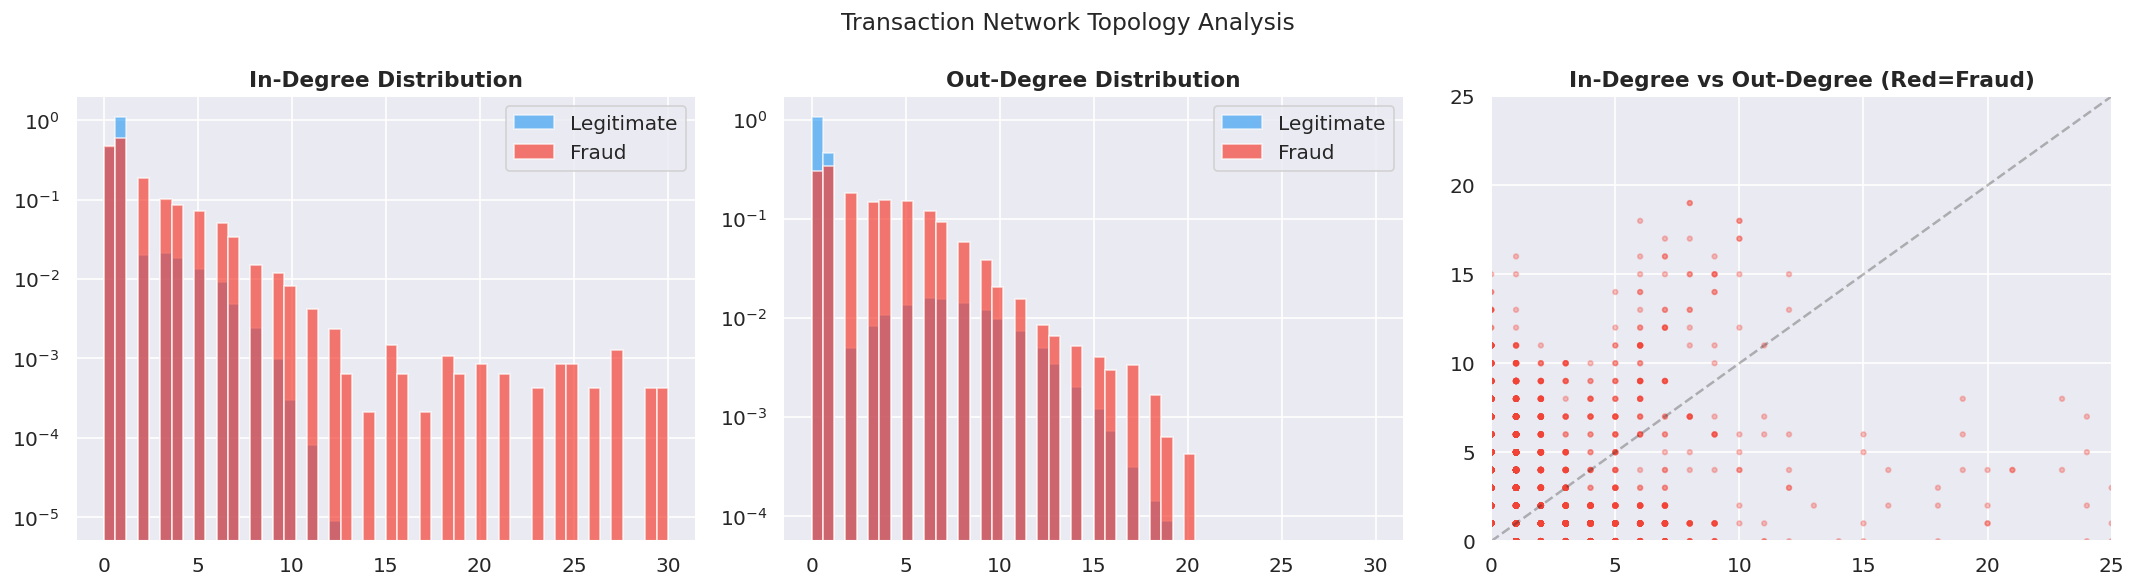

Metric                            Fraud    Legit
────────────────────────────────────────────────
  Avg In-Degree                    2.00     0.89
  Avg Out-Degree                   3.34     0.83
  Max In-Degree                      48       12
  Max Out-Degree                     20       19


In [5]:
in_deg  = dict(G.in_degree()); out_deg = dict(G.out_degree())
fraud_in  = [in_deg[n]  for n in G.nodes() if G.nodes[n]['is_fraud_node']]
legit_in  = [in_deg[n]  for n in G.nodes() if not G.nodes[n]['is_fraud_node']]
fraud_out = [out_deg[n] for n in G.nodes() if G.nodes[n]['is_fraud_node']]
legit_out = [out_deg[n] for n in G.nodes() if not G.nodes[n]['is_fraud_node']]

fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle("Transaction Network Topology Analysis", fontsize=14)

axes[0].hist(legit_in, bins=50, alpha=0.6, color='#2196F3', density=True, label='Legitimate', range=(0,30))
axes[0].hist(fraud_in, bins=50, alpha=0.7, color='#F44336', density=True, label='Fraud', range=(0,30))
axes[0].set_title("In-Degree Distribution"); axes[0].set_yscale('log'); axes[0].legend()

axes[1].hist(legit_out, bins=50, alpha=0.6, color='#2196F3', density=True, label='Legitimate', range=(0,30))
axes[1].hist(fraud_out, bins=50, alpha=0.7, color='#F44336', density=True, label='Fraud', range=(0,30))
axes[1].set_title("Out-Degree Distribution"); axes[1].set_yscale('log'); axes[1].legend()

sample_n = list(G.nodes())[:3000]
x = [in_deg[n] for n in sample_n]; y = [out_deg[n] for n in sample_n]
c = ['#F44336' if G.nodes[n]['is_fraud_node'] else '#2196F3' for n in sample_n]
axes[2].scatter(x, y, c=c, alpha=0.3, s=8)
axes[2].set_title("In-Degree vs Out-Degree (Red=Fraud)"); axes[2].set_xlim(0,25); axes[2].set_ylim(0,25)
axes[2].plot([0,25],[0,25],'k--',alpha=0.3)

plt.tight_layout(); plt.show()

print(f"{'Metric':<30} {'Fraud':>8} {'Legit':>8}")
print("─"*48)
for label, fd, ld in [("Avg In-Degree",fraud_in,legit_in),("Avg Out-Degree",fraud_out,legit_out)]:
    print(f"  {label:<28} {np.mean(fd):>8.2f} {np.mean(ld):>8.2f}")
for label, fd, ld in [("Max In-Degree",fraud_in,legit_in),("Max Out-Degree",fraud_out,legit_out)]:
    print(f"  {label:<28} {max(fd):>8d} {max(ld):>8d}")

## Suspicious Pattern Detection in the Graph

### AML typologies as graph signatures

Financial regulators (FinCEN, FATF) define laundering schemes by their structural patterns. We implement four detectors:

| Typology | Graph Signature | Detection Method |
|---|---|---|
| **Smurfing** | Many small in-edges summing above threshold | In-degree filter + amount analysis |
| **Layering chains** | High betweenness centrality (transit nodes) | Betweenness computation on subgraph |
| **U-turn / cycles** | Mutual edges A→B and B→A | Bidirectional edge detection |
| **Hub / mule** | High in-degree AND high out-degree simultaneously | Degree threshold combination |


In [6]:
STRUCTURING_THRESHOLD = 9_000
SMURF_MIN_EDGES = 3

# 1. Smurfing
smurf_nodes = set()
for node in G.nodes():
    in_edges = list(G.in_edges(node, data=True))
    if len(in_edges) >= SMURF_MIN_EDGES:
        avg_single = np.mean([d['total_amount']/d['tx_count'] for _,_,d in in_edges])
        total_in   = sum(d['total_amount'] for _,_,d in in_edges)
        if avg_single < STRUCTURING_THRESHOLD and total_in > STRUCTURING_THRESHOLD:
            smurf_nodes.add(node)

# 2. Layering (betweenness on subgraph for speed)
subgraph_nodes = list(G.nodes())[:5000]
SG = G.subgraph(subgraph_nodes)
betweenness = nx.betweenness_centrality(SG, normalized=True)
btw_threshold = np.percentile(list(betweenness.values()), 99)
layering_nodes = {n for n,b in betweenness.items() if b >= btw_threshold}

# 3. U-turn cycles
cycle_nodes = {n for u,v in G.edges() if G.has_edge(v,u) for n in (u,v)}

# 4. Hub/mule accounts
hub_nodes = {n for n in G.nodes() if G.in_degree(n) >= 5 and G.out_degree(n) >= 3}

print(f"[Smurfing]  Flagged: {len(smurf_nodes):,}")
print(f"[Layering]  High-betweenness (top 1%): {len(layering_nodes):,}")
print(f"[Cycles]    In mutual-edge cycles: {len(cycle_nodes):,}")
print(f"[Hub/Mule]  High-degree hubs: {len(hub_nodes):,}")

print("\n── Detector Evaluation ──────────────────────────────────────────────")
print(f"{'Detector':<15} {'Flagged':>8} {'Overlap':>8} {'Precision':>10} {'Recall':>10}")
print("─"*55)
for name, flagged in [("Smurfing",smurf_nodes),("Layering",layering_nodes),
                       ("Cycles",cycle_nodes),("Hub/Mule",hub_nodes)]:
    if not flagged: continue
    overlap   = len(flagged & fraud_accounts)
    precision = overlap/len(flagged)*100
    recall    = overlap/len(fraud_accounts)*100
    print(f"  {name:<13} {len(flagged):>8,} {overlap:>8,} {precision:>9.1f}% {recall:>9.1f}%")

[Smurfing]  Flagged: 3,858
[Layering]  High-betweenness (top 1%): 68
[Cycles]    In mutual-edge cycles: 2,881
[Hub/Mule]  High-degree hubs: 3,606

── Detector Evaluation ──────────────────────────────────────────────
Detector         Flagged  Overlap  Precision     Recall
───────────────────────────────────────────────────────
  Smurfing         3,858      742      19.2%       9.4%
  Layering            68       68     100.0%       0.9%
  Cycles           2,881      141       4.9%       1.8%
  Hub/Mule         3,606      343       9.5%       4.3%


Ego-graph around top fraud hub '6844529387': 223 nodes, 222 edges


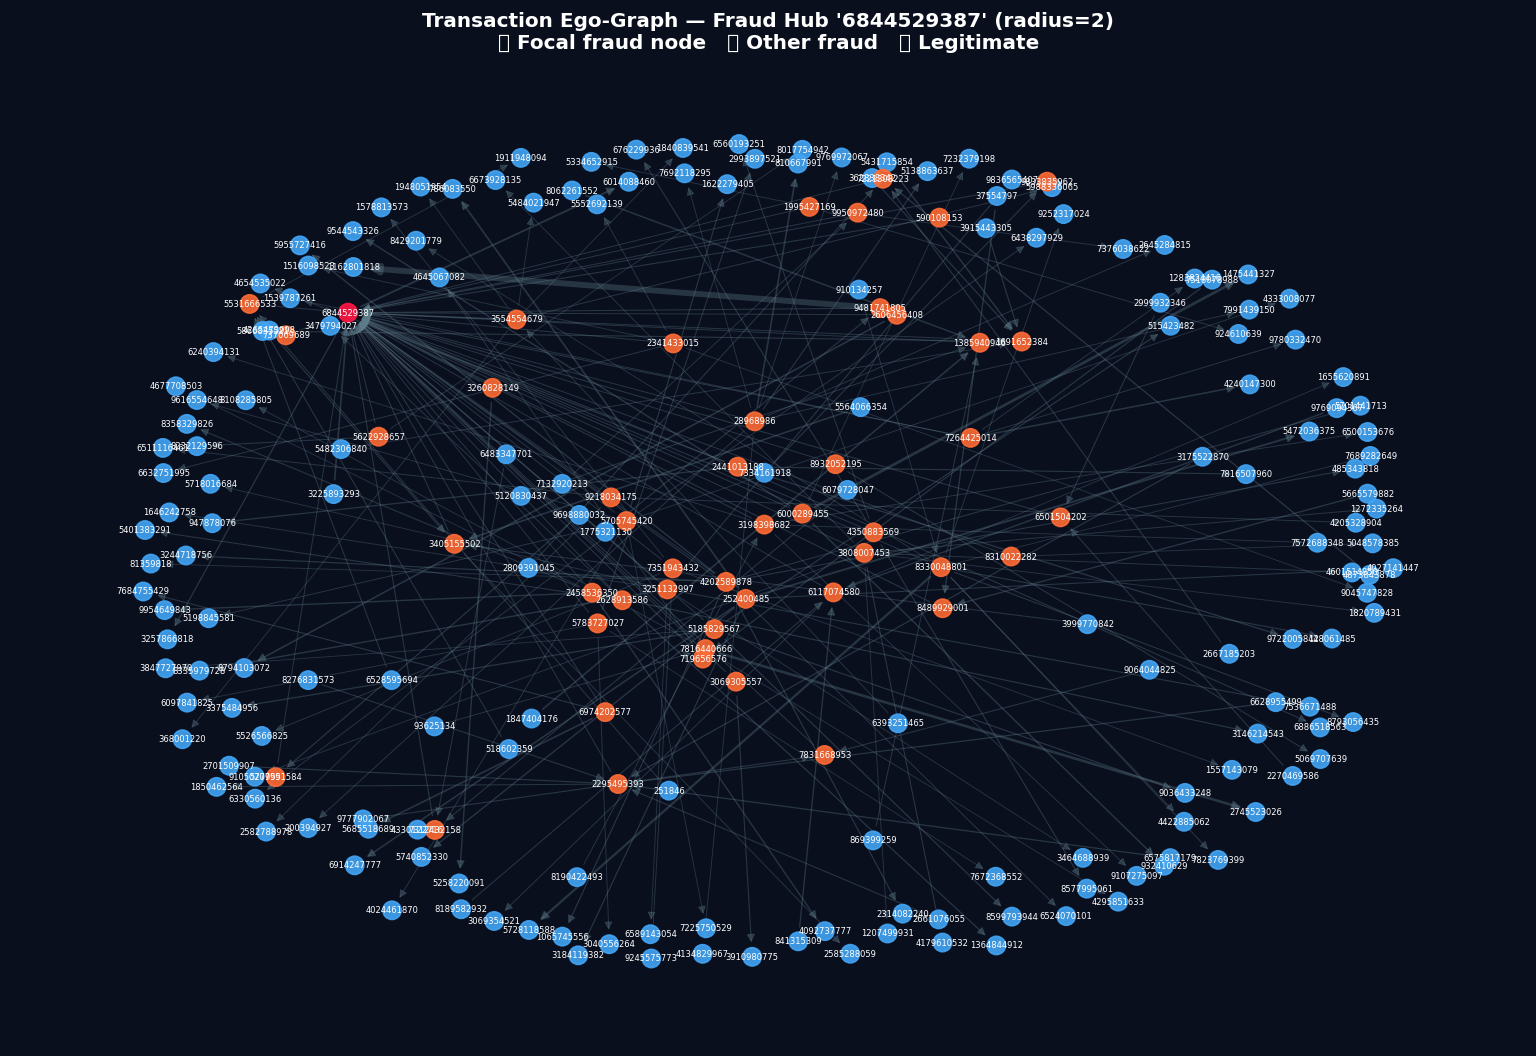

In [7]:
# Visualise suspicious subgraph
fraud_nodes_in_G = [n for n in G.nodes() if G.nodes[n]['is_fraud_node']]
if fraud_nodes_in_G:
    target = max(fraud_nodes_in_G, key=lambda n: G.in_degree(n) + G.out_degree(n))
    ego = nx.ego_graph(G, target, radius=2, undirected=True)
    print(f"Ego-graph around top fraud hub '{target}': {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")

    node_colors = ['#FF1744' if n==target else '#FF6B35' if ego.nodes[n].get('is_fraud_node') else '#42A5F5'
                   for n in ego.nodes()]
    edge_weights = [ego[u][v].get('total_amount',1) for u,v in ego.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [0.5 + 3.0*(w/max_w) for w in edge_weights]

    fig, ax = plt.subplots(figsize=(13,9))
    ax.set_facecolor('#0a0f1e'); fig.patch.set_facecolor('#0a0f1e')
    pos = nx.spring_layout(ego, seed=SEED, k=0.6)
    nx.draw_networkx_edges(ego, pos, alpha=0.35, edge_color='#607D8B',
        arrows=True, arrowsize=10, width=edge_widths, ax=ax)
    nx.draw_networkx_nodes(ego, pos, node_color=node_colors, node_size=120, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(ego, pos, font_size=5, font_color='white', ax=ax)
    ax.set_title(f"Transaction Ego-Graph — Fraud Hub '{target}' (radius=2)\n"
                 "🔴 Focal fraud node   🟠 Other fraud   🔵 Legitimate",
                 color='white', fontsize=12, fontweight='bold')
    ax.axis('off'); plt.tight_layout(); plt.show()

## Graph Feature Engineering

This is the **core contribution** — we extract per-account structural features and join them back to the transaction table.

| Feature | AML Intuition |
|---|---|
| `sender_in_degree` | How many accounts send to this sender → collection point signal |
| `sender_out_degree` | Fan-out breadth → layering signal |
| `sender_pagerank` | Importance in the money flow network |
| `sender_betweenness` | Transit/relay role |
| `sender_vol_in` / `vol_out` | Total USD processed |
| `sender_vol_ratio` | In/out volume asymmetry |
| `sender_is_smurf` | Structuring flag |
| `sender_is_hub` | Mule/hub flag |
| `sender_in_cycle` | U-turn participation |
| `edge_tx_count` | How often this exact corridor is reused |
| `edge_total_amt` | Total flow on this corridor |
| `edge_max_single` | Largest single transaction on this corridor |


In [8]:
print("Computing PageRank...")
pagerank = nx.pagerank(G, weight='total_amount', max_iter=100)

vol_in = defaultdict(float); vol_out = defaultdict(float)
for u,v,d in G.edges(data=True):
    vol_out[u] += d['total_amount']; vol_in[v] += d['total_amount']

btw_full = defaultdict(float, betweenness)

node_features = {
    n: {
        'in_degree'  : G.in_degree(n),  'out_degree' : G.out_degree(n),
        'total_degree': G.degree(n),     'pagerank'   : pagerank.get(n, 0.0),
        'betweenness': btw_full.get(n,0.0),
        'vol_in'     : vol_in.get(n,0.0), 'vol_out'  : vol_out.get(n,0.0),
        'vol_ratio'  : vol_in.get(n,0)/(vol_out.get(n,0)+1e-9),
        'is_smurf'   : int(n in smurf_nodes),
        'is_hub'     : int(n in hub_nodes),
        'in_cycle'   : int(n in cycle_nodes),
    } for n in G.nodes()
}
node_df = pd.DataFrame.from_dict(node_features, orient='index')
node_df.index.name = 'account'
print(f"Node feature table: {node_df.shape}"); print(node_df.describe().round(4))

Computing PageRank...
Node feature table: (194166, 11)
         in_degree   out_degree  total_degree     pagerank  betweenness  \
count  194166.0000  194166.0000   194166.0000  194166.0000     194166.0   
mean        0.9335       0.9335        1.8670       0.0000          0.0   
std         1.1720       2.2063        2.8633       0.0000          0.0   
min         0.0000       0.0000        1.0000       0.0000          0.0   
25%         0.0000       0.0000        1.0000       0.0000          0.0   
50%         1.0000       0.0000        1.0000       0.0000          0.0   
75%         1.0000       1.0000        1.0000       0.0000          0.0   
max        48.0000      20.0000       50.0000       0.0002          0.0   

             vol_in       vol_out     vol_ratio     is_smurf       is_hub  \
count  1.941660e+05  1.941660e+05  1.941660e+05  194166.0000  194166.0000   
mean   1.109541e+04  1.109541e+04  6.172568e+12       0.0199       0.0186   
std    9.845244e+04  1.020838e+05  2.9

In [9]:
def join_graph_features(df, node_df, G):
    df = df.copy()
    df['Sender_account']   = df['Sender_account'].astype(str)
    df['Receiver_account'] = df['Receiver_account'].astype(str)
    df = df.merge(node_df.add_prefix('sender_'),   left_on='Sender_account',   right_index=True, how='left')
    df = df.merge(node_df.add_prefix('receiver_'), left_on='Receiver_account', right_index=True, how='left')
    edge_data = {(str(u),str(v)): d for u,v,d in G.edges(data=True)}
    pairs = list(zip(df['Sender_account'], df['Receiver_account']))
    df['edge_tx_count']   = [edge_data.get(p,{}).get('tx_count',0)      for p in pairs]
    df['edge_total_amt']  = [edge_data.get(p,{}).get('total_amount',0)  for p in pairs]
    df['edge_max_single'] = [edge_data.get(p,{}).get('max_single_tx',0) for p in pairs]
    return df

enriched_df = join_graph_features(sample_df, node_df, G)

# Convert any Categorical columns to string before filling NaNs
for col in enriched_df.select_dtypes(include='category').columns:
    enriched_df[col] = enriched_df[col].astype(str)

enriched_df.fillna(0, inplace=True)

## Feature Preparation & SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic fraud examples by interpolating between real fraud transactions in feature space — correcting the 961:1 class imbalance without losing information from the majority class.

In [12]:
drop_cols = ['Is_laundering', 'Sender_account', 'Receiver_account', 'Laundering_type',
             'Date', 'Time', 'Amount_log', 'amount_tier']
drop_cols = [c for c in drop_cols if c in enriched_df.columns]

X_full = enriched_df.drop(columns=drop_cols)
y      = enriched_df['Is_laundering']

graph_feature_cols = [c for c in enriched_df.columns if c.startswith(('sender_', 'receiver_', 'edge_'))]

cat_cols = X_full.select_dtypes(include='object').columns.tolist()
num_cols = X_full.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Total features : {X_full.shape[1]}  |  Categorical: {len(cat_cols)}  |  Numeric: {len(num_cols)}")
print(f"Graph-derived  : {len(graph_feature_cols)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=SEED, stratify=y)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

maj_idx     = np.where(y_train == 0)[0]
min_idx     = np.where(y_train == 1)[0]
sampled_maj = np.random.choice(maj_idx, size=min(50_000, len(maj_idx)), replace=False)
sample_idx  = np.concatenate([sampled_maj, min_idx])

X_sm = X_train_proc[sample_idx]
y_sm = y_train.iloc[sample_idx]

X_train_smote, y_train_smote = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(X_sm, y_sm)
print(f"\nAfter SMOTE — Legit: {(y_train_smote==0).sum():,}  |  Fraud: {(y_train_smote==1).sum():,}")

Total features : 35  |  Categorical: 5  |  Numeric: 28
Graph-derived  : 25

After SMOTE — Legit: 50,000  |  Fraud: 50,000


## XGBoost Classifier

XGBoost builds an ensemble of decision trees sequentially, each correcting the errors of the previous. The `scale_pos_weight` parameter penalises missing a fraud case more heavily than producing a false alarm.

**AML-specific hyperparameters:**
- `max_depth=5` — shallow trees prevent overfitting on graph features
- `colsample_bytree=0.8` — random feature selection improves generalisation
- Threshold tuned to maximise precision within an 85–92% recall band


In [14]:
def select_threshold(y_true, y_prob, low=0.85, high=0.92):
    pr, rec, thr = precision_recall_curve(y_true, y_prob)
    cands = [(thr[i], pr[i], rec[i]) for i, r in enumerate(rec[:-1]) if low <= r <= high]
    if cands:
        return max(cands, key=lambda x: x[1])
    bi = np.argmax(rec)
    t = thr[bi] if bi < len(thr) else 0.5
    return t, pr[bi], rec[bi]

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
    colsample_bytree=0.8, subsample=0.8, use_label_encoder=False,
    eval_metric='aucpr', random_state=SEED, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_smote, y_train_smote, eval_set=[(X_test_proc, y_test)], verbose=False)

y_prob_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
bt, _, _   = select_threshold(y_test, y_prob_xgb)
y_pred_xgb = (y_prob_xgb >= bt).astype(int)

print(f"XGBoost threshold: {bt:.3f}")
results.append(full_eval("XGBoost + Graph Features", y_test, y_pred_xgb, y_prob_xgb))

XGBoost threshold: 0.997

═══════════════════════════════════════════════════════
  XGBoost + Graph Features
═══════════════════════════════════════════════════════
  Frauds caught (TP): 1,748  |  Missed (FN): 227
  False alarms  (FP): 0  |  True neg   : 40,000
  Recall: 0.8851  Precision: 1.0000  F2: 0.9059  ROC-AUC: 0.9991
              precision    recall  f1-score   support

  Legitimate     0.9944    1.0000    0.9972     40000
       Fraud     1.0000    0.8851    0.9390      1975

    accuracy                         0.9946     41975
   macro avg     0.9972    0.9425    0.9681     41975
weighted avg     0.9946    0.9946    0.9944     41975



## LightGBM Classifier

LightGBM uses **leaf-wise** tree growth — faster on large datasets. `is_unbalance=True` automatically up-weights the minority class, complementing the SMOTE-balanced training data.

In [16]:
lgb_model = lgb.LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
    colsample_bytree=0.8, subsample=0.8, is_unbalance=True,
    class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_smote, y_train_smote, eval_set=[(X_test_proc, y_test)],
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(period=-1)])

y_prob_lgb = lgb_model.predict_proba(X_test_proc)[:, 1]
bt, _, _   = select_threshold(y_test, y_prob_lgb)
y_pred_lgb = (y_prob_lgb >= bt).astype(int)

print(f"LightGBM threshold: {bt:.3f}")
results.append(full_eval("LightGBM + Graph Features", y_test, y_pred_lgb, y_prob_lgb))

LightGBM threshold: 0.998

═══════════════════════════════════════════════════════
  LightGBM + Graph Features
═══════════════════════════════════════════════════════
  Frauds caught (TP): 1,794  |  Missed (FN): 181
  False alarms  (FP): 0  |  True neg   : 40,000
  Recall: 0.9084  Precision: 1.0000  F2: 0.9253  ROC-AUC: 0.9989
              precision    recall  f1-score   support

  Legitimate     0.9955    1.0000    0.9977     40000
       Fraud     1.0000    0.9084    0.9520      1975

    accuracy                         0.9957     41975
   macro avg     0.9977    0.9542    0.9749     41975
weighted avg     0.9957    0.9957    0.9956     41975



## CatBoost Classifier

CatBoost handles categorical features natively via **ordered target statistics**. `auto_class_weights='Balanced'` produces well-calibrated probabilities — critical for threshold-based AML systems.

In [18]:
cat_model = CatBoostClassifier(iterations=300, depth=5, learning_rate=0.08,
    auto_class_weights='Balanced', random_state=SEED, verbose=0)
cat_model.fit(X_train_smote, y_train_smote, eval_set=(X_test_proc, y_test), use_best_model=True)

y_prob_cat = cat_model.predict_proba(X_test_proc)[:, 1]
bt, _, _   = select_threshold(y_test, y_prob_cat)
y_pred_cat = (y_prob_cat >= bt).astype(int)

print(f"CatBoost threshold: {bt:.3f}")
results.append(full_eval("CatBoost + Graph Features", y_test, y_pred_cat, y_prob_cat))

CatBoost threshold: 0.990

═══════════════════════════════════════════════════════
  CatBoost + Graph Features
═══════════════════════════════════════════════════════
  Frauds caught (TP): 1,815  |  Missed (FN): 160
  False alarms  (FP): 0  |  True neg   : 40,000
  Recall: 0.9190  Precision: 1.0000  F2: 0.9341  ROC-AUC: 0.9983
              precision    recall  f1-score   support

  Legitimate     0.9960    1.0000    0.9980     40000
       Fraud     1.0000    0.9190    0.9578      1975

    accuracy                         0.9962     41975
   macro avg     0.9980    0.9595    0.9779     41975
weighted avg     0.9962    0.9962    0.9961     41975



## Model Comparison & Evaluation Dashboard

                           Recall  Precision      F1      F2  ROC-AUC  PR-AUC    TP  FP   FN
Model                                                                                       
XGBoost + Graph Features   0.8851        1.0  0.9390  0.9059   0.9991  0.9954  1748   0  227
LightGBM + Graph Features  0.9084        1.0  0.9520  0.9253   0.9989  0.9951  1794   0  181
CatBoost + Graph Features  0.9190        1.0  0.9578  0.9341   0.9983  0.9943  1815   0  160


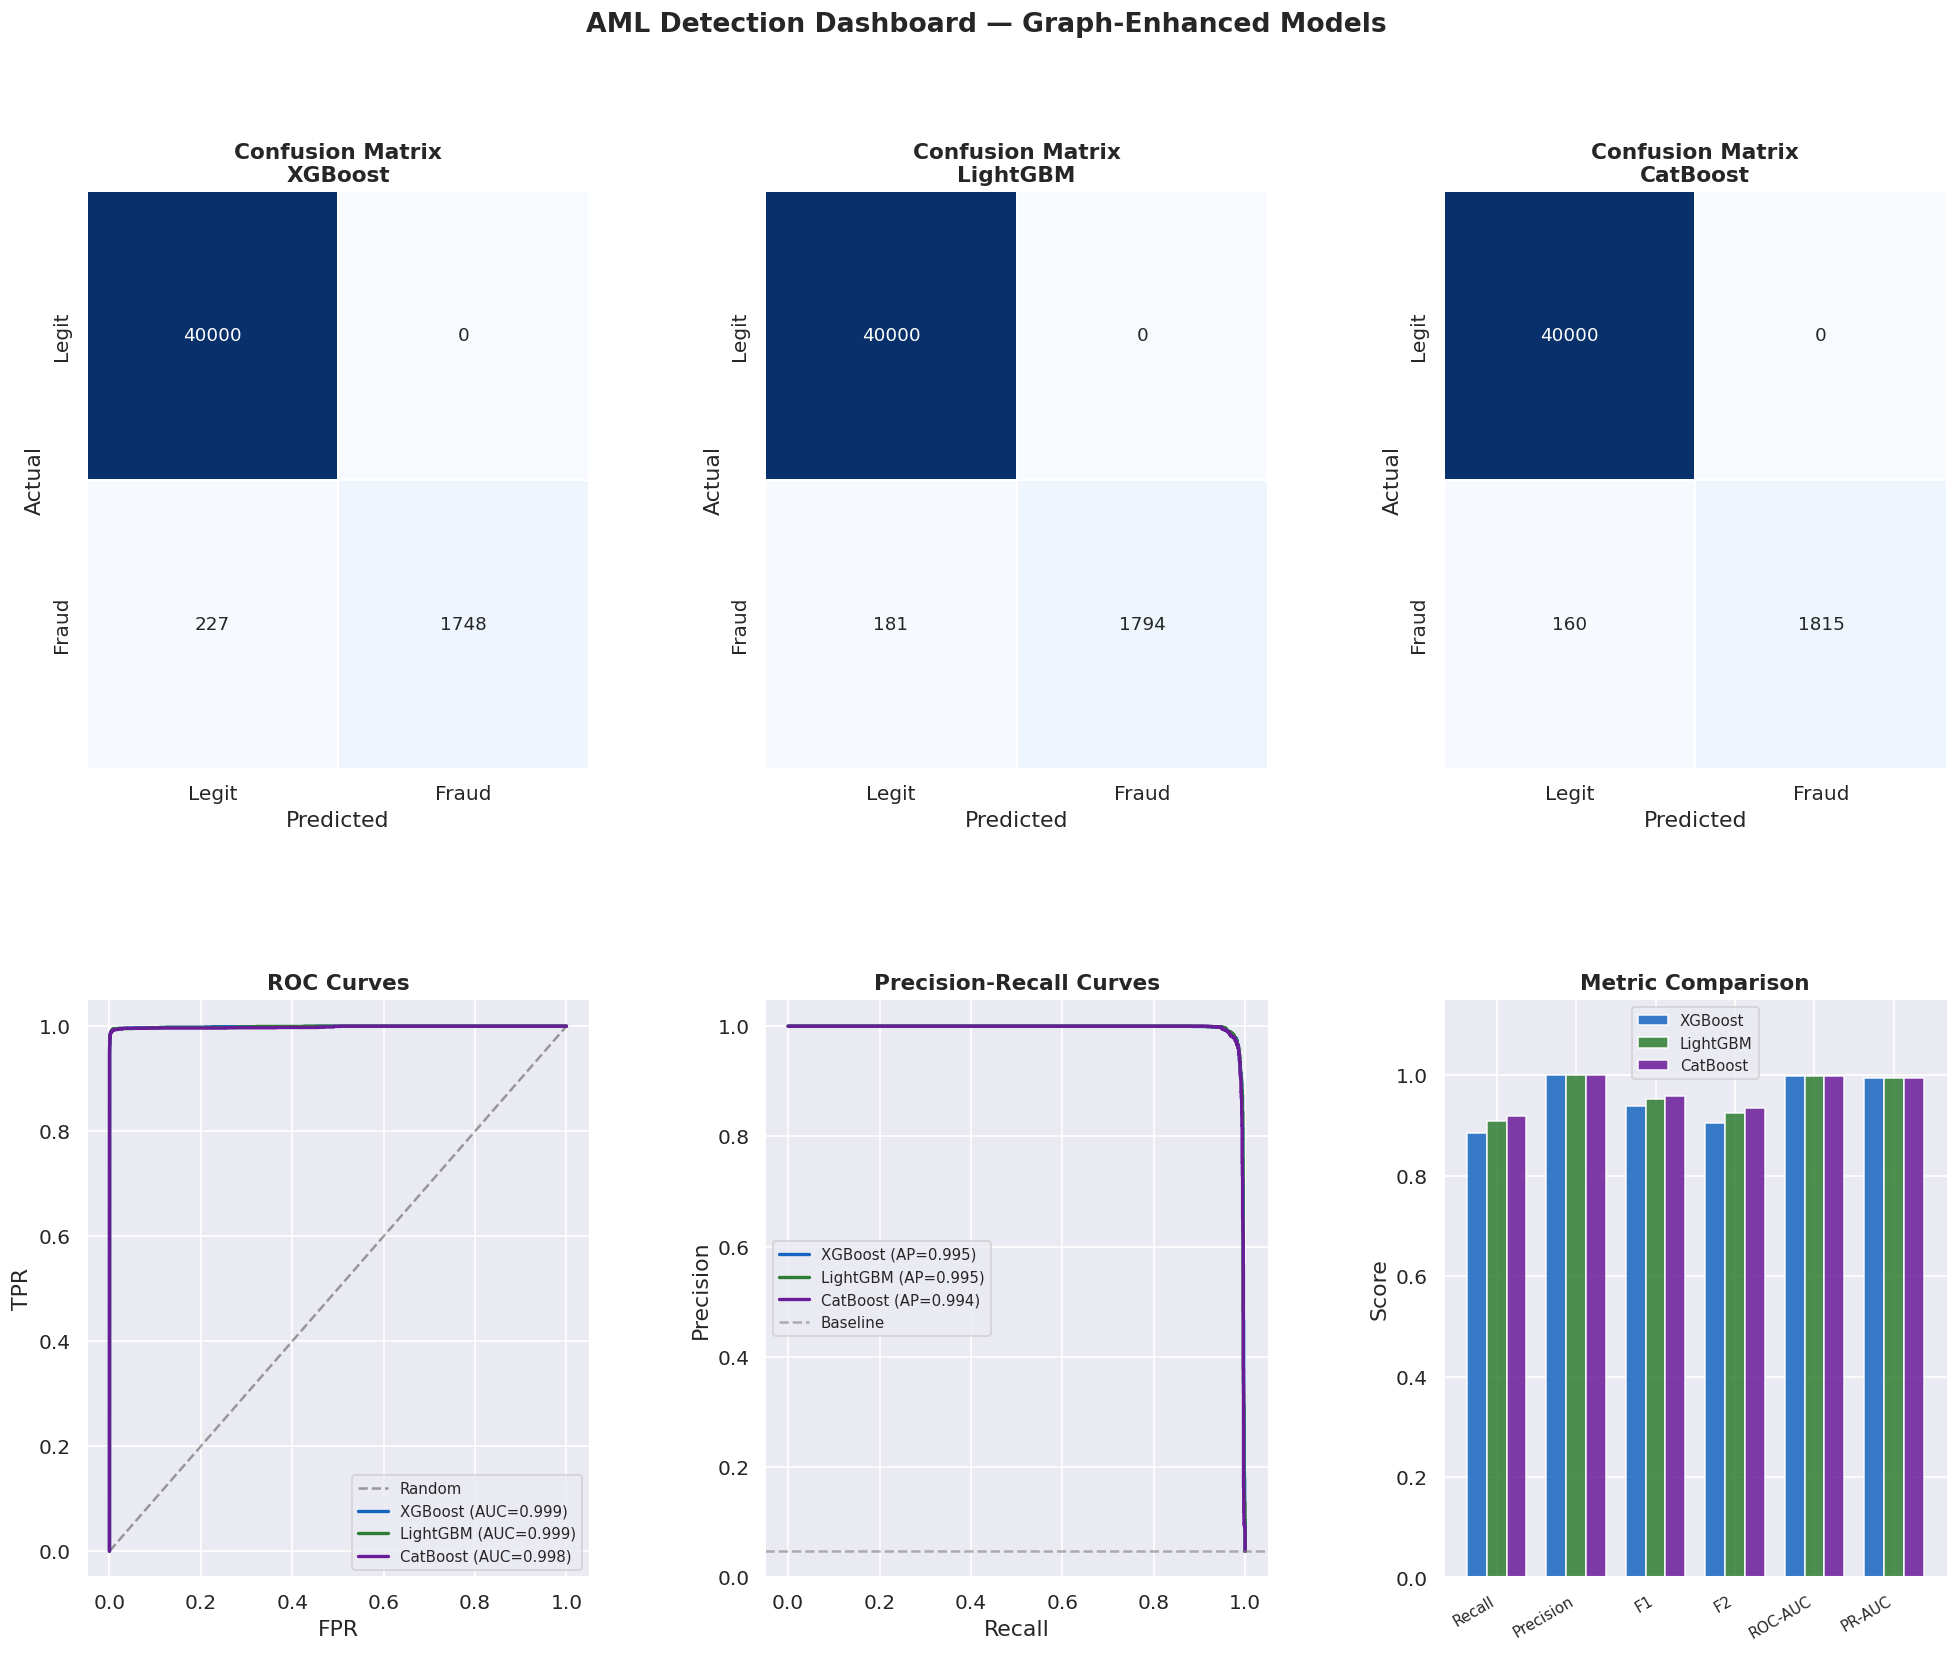

In [19]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df[['Recall','Precision','F1','F2','ROC-AUC','PR-AUC','TP','FP','FN']].round(4).to_string())

fig = plt.figure(figsize=(20,15))
fig.suptitle("AML Detection Dashboard — Graph-Enhanced Models",fontsize=16,fontweight='bold',y=0.98)
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.35)
short_names = ["XGBoost","LightGBM","CatBoost"]
colors      = ['#1565C0','#2E7D32','#6A1B9A']
model_probas= [y_prob_xgb,y_prob_lgb,y_prob_cat]
model_preds = [y_pred_xgb,y_pred_lgb,y_pred_cat]

for idx in range(3):
    ax = fig.add_subplot(gs[0,idx])
    cm = confusion_matrix(y_test,model_preds[idx])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
        xticklabels=['Legit','Fraud'],yticklabels=['Legit','Fraud'],
        linewidths=1,cbar=False,annot_kws={'size':11})
    ax.set_title(f"Confusion Matrix\n{short_names[idx]}",fontweight='bold')
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

ax_roc = fig.add_subplot(gs[1,0])
ax_roc.plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
for i,(p,n,c) in enumerate(zip(model_probas,short_names,colors)):
    fpr,tpr,_ = roc_curve(y_test,p)
    ax_roc.plot(fpr,tpr,color=c,linewidth=2,label=f"{n} (AUC={results_df.iloc[i]['ROC-AUC']:.3f})")
ax_roc.set_title("ROC Curves"); ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.legend(fontsize=9); sns.despine(ax=ax_roc)

ax_pr = fig.add_subplot(gs[1,1])
for i,(p,n,c) in enumerate(zip(model_probas,short_names,colors)):
    pr_p,pr_r,_ = precision_recall_curve(y_test,p)
    ax_pr.plot(pr_r,pr_p,color=c,linewidth=2,label=f"{n} (AP={results_df.iloc[i]['PR-AUC']:.3f})")
ax_pr.axhline(y_test.mean(),color='gray',linestyle='--',alpha=0.6,label='Baseline')
ax_pr.set_title("Precision-Recall Curves"); ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.legend(fontsize=9); sns.despine(ax=ax_pr)

ax_bar = fig.add_subplot(gs[1,2])
metrics_p = ['Recall','Precision','F1','F2','ROC-AUC','PR-AUC']
x = np.arange(len(metrics_p)); w = 0.25
for i,(n,c) in enumerate(zip(short_names,colors)):
    vals = [results_df.iloc[i][m] for m in metrics_p]
    ax_bar.bar(x+i*w-w,vals,w,label=n,color=c,alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metrics_p,rotation=30,ha='right',fontsize=9)
ax_bar.set_ylim(0,1.15); ax_bar.set_ylabel("Score"); ax_bar.set_title("Metric Comparison")
ax_bar.legend(fontsize=9); sns.despine(ax=ax_bar)
plt.tight_layout(); plt.show()

## Graph-Enhanced Feature Importance

Feature importance reveals which signals the model relies on most. Graph features are highlighted in orange — their ranking quantifies the **lift from network analysis** over tabular-only approaches.

If graph features like PageRank, betweenness, or in-degree rank highly, it confirms that **network position is a strong predictor of laundering activity**.


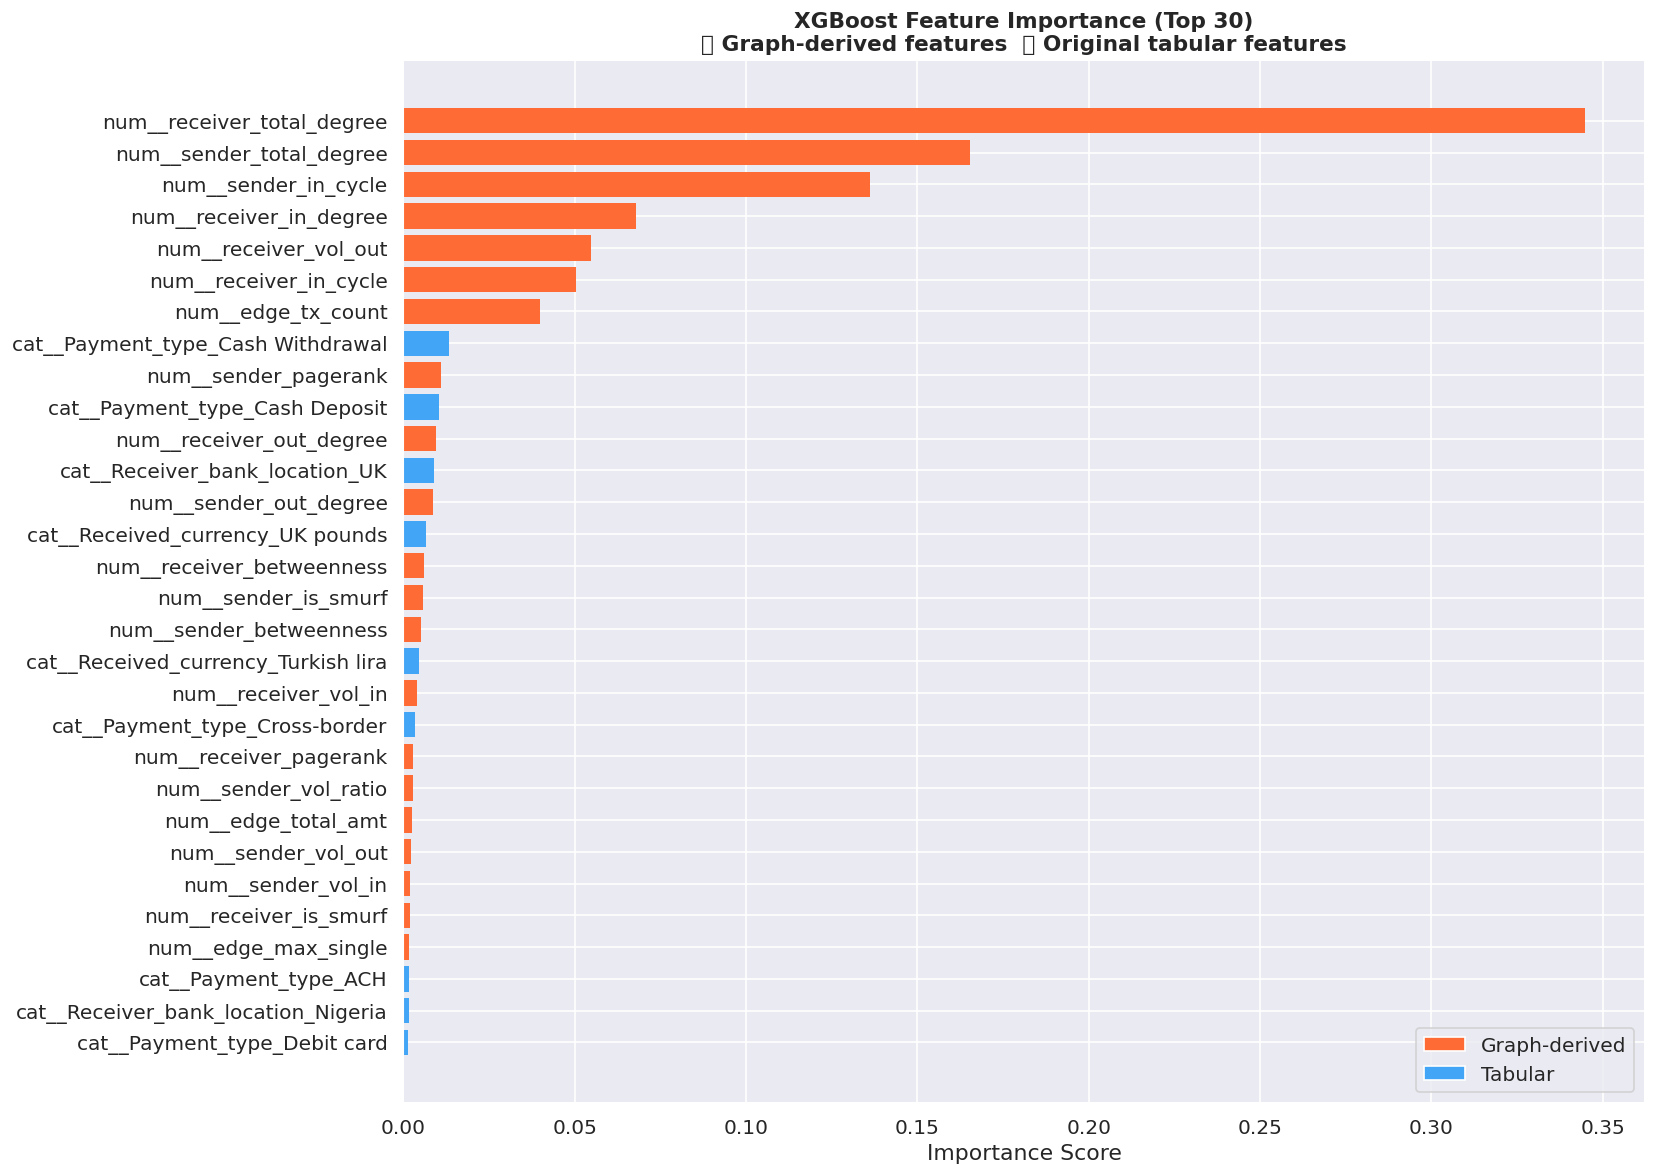

Graph feature contribution to top-30 importance: 94.7%


In [20]:
feature_names = preprocessor.get_feature_names_out()
importances   = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature':feature_names,'Importance':importances})
fi_df = fi_df.sort_values('Importance',ascending=False).head(30)
fi_df['Is_Graph'] = fi_df['Feature'].apply(
    lambda f: any(f.startswith(f'num__{g}') for g in ['sender_','receiver_','edge_']))

fig, ax = plt.subplots(figsize=(14,10))
bar_colors = ['#FF6B35' if g else '#42A5F5' for g in fi_df['Is_Graph']]
ax.barh(fi_df['Feature'],fi_df['Importance'],color=bar_colors,edgecolor='none')
ax.invert_yaxis()
ax.set_title("XGBoost Feature Importance (Top 30)\n🟠 Graph-derived features  🔵 Original tabular features",
             fontweight='bold',fontsize=13)
ax.set_xlabel("Importance Score")
ax.legend(handles=[Patch(facecolor='#FF6B35',label='Graph-derived'),
                   Patch(facecolor='#42A5F5',label='Tabular')],loc='lower right')
sns.despine(); plt.tight_layout(); plt.show()

graph_imp = fi_df[fi_df['Is_Graph']]['Importance'].sum()
total_imp  = fi_df['Importance'].sum()
print(f"Graph feature contribution to top-30 importance: {graph_imp/total_imp*100:.1f}%")


### References

- Weber et al. (2019). *Anti-Money Laundering in Bitcoin: Experimenting with Graph Convolutional Networks.* KDD Workshop.
- Pareja et al. (2020). *EvolveGCN: Evolving Graph Convolutional Networks for Dynamic Graphs.* AAAI.
- FATF (2022). *Money Laundering and Terrorist Financing Typologies.* Financial Action Task Force.
- Baesens et al. (2015). *Fraud Analytics Using Descriptive, Predictive, and Social Network Techniques.* Wiley.

